# **SuperKart Sales Forecasting & Model Deployment**

# **Problem Statement**

## Business Context

A sales forecast predicts future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. An accurate forecast adds value across the organisation and helps the different verticals chalk out their future course of action.

Forecasting helps an organisation plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast improves decision-making, reduces sales pipeline and forecast risks, reduces the time spent planning territory coverage, and establishes benchmarks for assessing future trends.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimise its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalise these insights at scale, SuperKart has partnered with a data science firm not only to build a predictive model on historical sales data but also to **develop and deploy a robust forecasting solution** (Flask backend + Streamlit frontend, containerised with Docker and deployed in GitHub Codespaces) that can be integrated into SuperKart's decision-making systems.

## Data Description

- **Product_Id** - unique identifier of each product (two letters followed by a number)
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product (low sugar, regular, no sugar)
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all products in a store
- **Product_Type** - broad category of each product (meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others)
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store (High, Medium, Small)
- **Store_Location_City_Type** - type of city (Tier 1, Tier 2, Tier 3); Tier 1 cities have the highest standard of living
- **Store_Type** - Departmental Store, Supermarket Type 1, Supermarket Type 2, Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that product in that store (**target**)

# **1. Installing and Importing the Necessary Libraries**

In [1]:
# Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 -q

**Note:** After running the above cell, restart the kernel/runtime and run all cells sequentially from the next cell. Any dependency-resolver warnings printed by pip can be ignored.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Splitting and tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)

# Pipelines and preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

# Serialisation, OS utilities, API requests
import joblib
import os
import json
import requests

import sklearn, xgboost
print("numpy:", np.__version__, "| pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__,
      "| xgboost:", xgboost.__version__, "| joblib:", joblib.__version__)

numpy: 2.0.2 | pandas: 2.2.2 | scikit-learn: 1.6.1 | xgboost: 2.1.4 | joblib: 1.4.2


# **2. Loading the Dataset**

In [3]:
# Load the SuperKart historical sales data
df = pd.read_csv("SuperKart.csv")

# Keep an untouched copy of the raw data for reference
data = df.copy()
print("Dataset loaded successfully.")

Dataset loaded successfully.


# **3. Data Overview**

### Shape of the data

In [4]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 8763 rows and 12 columns.


### First and last 5 rows

In [5]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.660,Low Sugar,0.027,Frozen Foods,117.080,OUT004,2009,Medium,Tier 2,Supermarket Type2,"2,842.400"
1,FD7839,16.540,Low Sugar,0.144,Dairy,171.430,OUT003,1999,Medium,Tier 1,Departmental Store,"4,830.020"
2,FD5075,14.280,Regular,0.031,Canned,162.080,OUT001,1987,High,Tier 2,Supermarket Type1,"4,130.160"
3,FD8233,12.100,Low Sugar,0.112,Baking Goods,186.310,OUT001,1987,High,Tier 2,Supermarket Type1,"4,132.180"
4,NC1180,9.570,No Sugar,0.010,Health and Hygiene,123.670,OUT002,1998,Small,Tier 3,Food Mart,"2,279.360"


In [6]:
df.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.800,No Sugar,0.016,Health and Hygiene,140.530,OUT004,2009,Medium,Tier 2,Supermarket Type2,"3,806.530"
8759,NC584,14.060,No Sugar,0.142,Household,144.510,OUT004,2009,Medium,Tier 2,Supermarket Type2,"5,020.740"
8760,NC2471,13.480,No Sugar,0.017,Health and Hygiene,88.580,OUT001,1987,High,Tier 2,Supermarket Type1,"2,443.420"
8761,NC7187,13.890,No Sugar,0.193,Household,168.440,OUT001,1987,High,Tier 2,Supermarket Type1,"4,171.820"
8762,FD306,14.730,Low Sugar,0.177,Snack Foods,224.930,OUT002,1998,Small,Tier 3,Food Mart,"2,186.080"


### Data types

In [7]:
df.dtypes

Product_Id                    object
Product_Weight               float64
Product_Sugar_Content         object
Product_Allocated_Area       float64
Product_Type                  object
Product_MRP                  float64
Store_Id                      object
Store_Establishment_Year       int64
Store_Size                    object
Store_Location_City_Type      object
Store_Type                    object
Product_Store_Sales_Total    float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


**Observations:**
- 8,763 rows and 12 columns; each row is a product-store combination.
- 5 numerical columns (`Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, `Store_Establishment_Year`, `Product_Store_Sales_Total`) and 7 object (categorical/ID) columns.
- `Store_Establishment_Year` is stored as an integer, but it is better represented as the age of the store (engineered later).

### Missing values

In [9]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
})
missing

,Missing Count,Missing %
Product_Id,0,0.000
Product_Weight,0,0.000
Product_Sugar_Content,0,0.000
Product_Allocated_Area,0,0.000
Product_Type,0,0.000
Product_MRP,0,0.000
Store_Id,0,0.000
Store_Establishment_Year,0,0.000
Store_Size,0,0.000
Store_Location_City_Type,0,0.000


### Duplicate rows

In [10]:
print("Number of fully duplicated rows:", df.duplicated().sum())
print("Number of unique Product_Ids    :", df["Product_Id"].nunique(), "out of", len(df), "rows")

Number of fully duplicated rows: 0
Number of unique Product_Ids    : 8763 out of 8763 rows


### Statistical summary - numerical columns

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,"8,763.000",12.654,2.217,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,"8,763.000",0.069,0.048,0.004,0.031,0.056,0.096,0.298
Product_MRP,"8,763.000",147.033,30.694,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,"8,763.000","2,002.033",8.388,"1,987.000","1,998.000","2,009.000","2,009.000","2,009.000"
Product_Store_Sales_Total,"8,763.000","3,464.004","1,065.630",33.000,"2,761.715","3,452.340","4,145.165","8,000.000"


### Statistical summary - categorical columns

In [12]:
df.describe(include="object").T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


In [13]:
# Unique values in each low-cardinality categorical column
for col in ["Product_Sugar_Content", "Product_Type", "Store_Id", "Store_Size", "Store_Location_City_Type", "Store_Type"]:
    print(f"{col}: {sorted(df[col].unique())}\n")

Product_Sugar_Content: ['Low Sugar', 'No Sugar', 'Regular', 'reg']

Product_Type: ['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy', 'Frozen Foods', 'Fruits and Vegetables', 'Hard Drinks', 'Health and Hygiene', 'Household', 'Meat', 'Others', 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']

Store_Id: ['OUT001', 'OUT002', 'OUT003', 'OUT004']

Store_Size: ['High', 'Medium', 'Small']

Store_Location_City_Type: ['Tier 1', 'Tier 2', 'Tier 3']

Store_Type: ['Departmental Store', 'Food Mart', 'Supermarket Type1', 'Supermarket Type2']



In [14]:
# How do the store-level attributes relate to each other?
df.groupby(["Store_Id", "Store_Type", "Store_Size", "Store_Location_City_Type", "Store_Establishment_Year"]).size().reset_index(name="Rows")

,Store_Id,Store_Type,Store_Size,Store_Location_City_Type,Store_Establishment_Year,Rows
0,OUT001,Supermarket Type1,High,Tier 2,1987,1586
1,OUT002,Food Mart,Small,Tier 3,1998,1152
2,OUT003,Departmental Store,Medium,Tier 1,1999,1349
3,OUT004,Supermarket Type2,Medium,Tier 2,2009,4676


**Observations:**
- **No missing values** in any column, and **no duplicate rows**; every `Product_Id` is unique, so it is an identifier and carries no repeated-product signal.
- `Product_Weight` ranges ~4-22 (mean ~12.65), `Product_MRP` ranges ~31-266 (mean ~147), and `Product_Allocated_Area` ranges 0.004-0.298 (mean ~0.069, median lower than mean, i.e. right skewed).
- Target `Product_Store_Sales_Total` ranges ~33 to 8,000 with a mean of ~3,464.
- `Product_Sugar_Content` has an inconsistent label **`reg`** (108 rows) which is the same as **`Regular`** - it is cleaned below.
- There are only **4 stores**, and store attributes are fully determined by `Store_Id` (e.g. OUT004 is the only Supermarket Type2, Medium, Tier 2, est. 2009, with 4,676 rows - 53% of the data). Store-level features will therefore act like a store identifier in the model.

In [15]:
# Data cleaning: standardise the inconsistent sugar-content label
df["Product_Sugar_Content"] = df["Product_Sugar_Content"].replace({"reg": "Regular"})
df["Product_Sugar_Content"].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

# **4. Exploratory Data Analysis (EDA)**

## Univariate Analysis

### Distribution plots of numerical variables

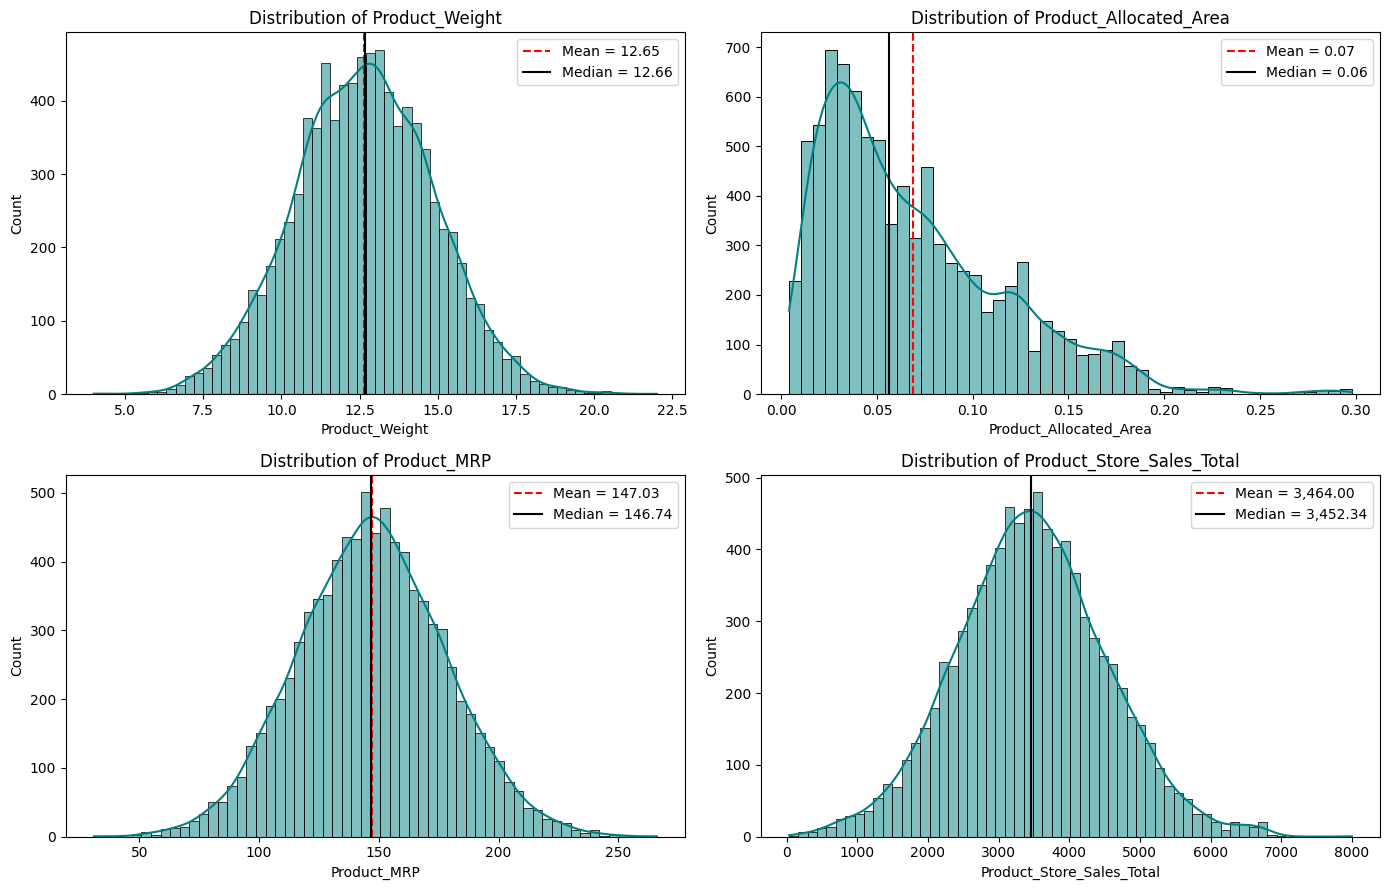

Skewness:
Product_Weight              0.018
Product_Allocated_Area      1.128
Product_MRP                 0.037
Product_Store_Sales_Total   0.092
dtype: float64


In [16]:
num_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Product_Store_Sales_Total"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="teal")
    ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean = {df[col].mean():,.2f}")
    ax.axvline(df[col].median(), color="black", linestyle="-", label=f"Median = {df[col].median():,.2f}")
    ax.set_title(f"Distribution of {col}")
    ax.legend()
plt.tight_layout()
plt.show()

print("Skewness:")
print(df[num_cols].skew().round(3))

### Boxplots of numerical variables

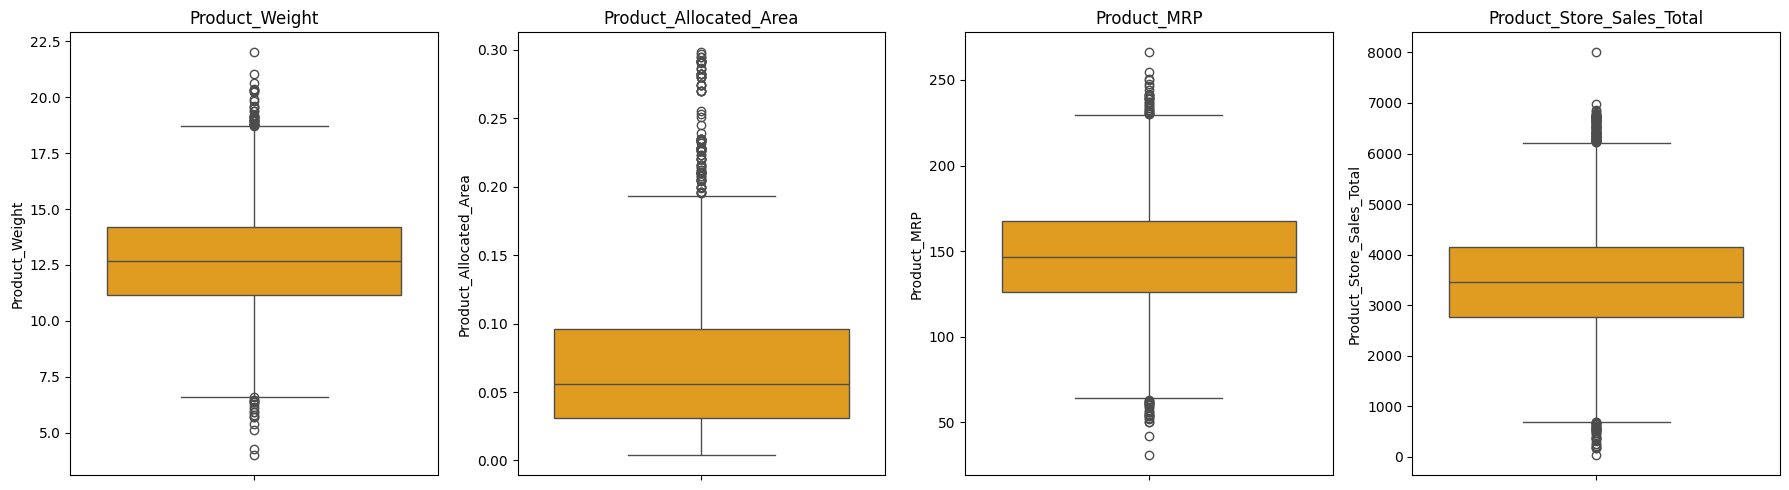

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="orange")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Observations:**
- `Product_Weight`, `Product_MRP` and `Product_Store_Sales_Total` are roughly **symmetric / bell-shaped** (skewness close to 0); mean and median almost coincide.
- `Product_Allocated_Area` is **right-skewed** (skewness > 1): most products get a small share of display area, a few get a large share.
- All four variables show some points beyond the boxplot whiskers; these look like plausible extreme values rather than data-entry errors (no negative or impossible values).

### Categorical variables - counts and bar charts

In [18]:
cat_cols = ["Product_Sugar_Content", "Product_Type", "Store_Size", "Store_Location_City_Type", "Store_Type"]

for col in cat_cols:
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(2)
    print(f"--- {col} ---")
    print(pd.DataFrame({"Count": counts, "%": pct}), "\n")

--- Product_Sugar_Content ---
                       Count      %
Product_Sugar_Content              
Low Sugar               4885 55.750
Regular                 2359 26.920
No Sugar                1519 17.330 

--- Product_Type ---
                       Count      %
Product_Type                       
Fruits and Vegetables   1249 14.250
Snack Foods             1149 13.110
Frozen Foods             811  9.250
Dairy                    796  9.080
Household                740  8.440
Baking Goods             716  8.170
Canned                   677  7.730
Health and Hygiene       628  7.170
Meat                     618  7.050
Soft Drinks              519  5.920
Breads                   200  2.280
Hard Drinks              186  2.120
Others                   151  1.720
Starchy Foods            141  1.610
Breakfast                106  1.210
Seafood                   76  0.870 

--- Store_Size ---
            Count      %
Store_Size              
Medium       6025 68.750
High         1586 18.10

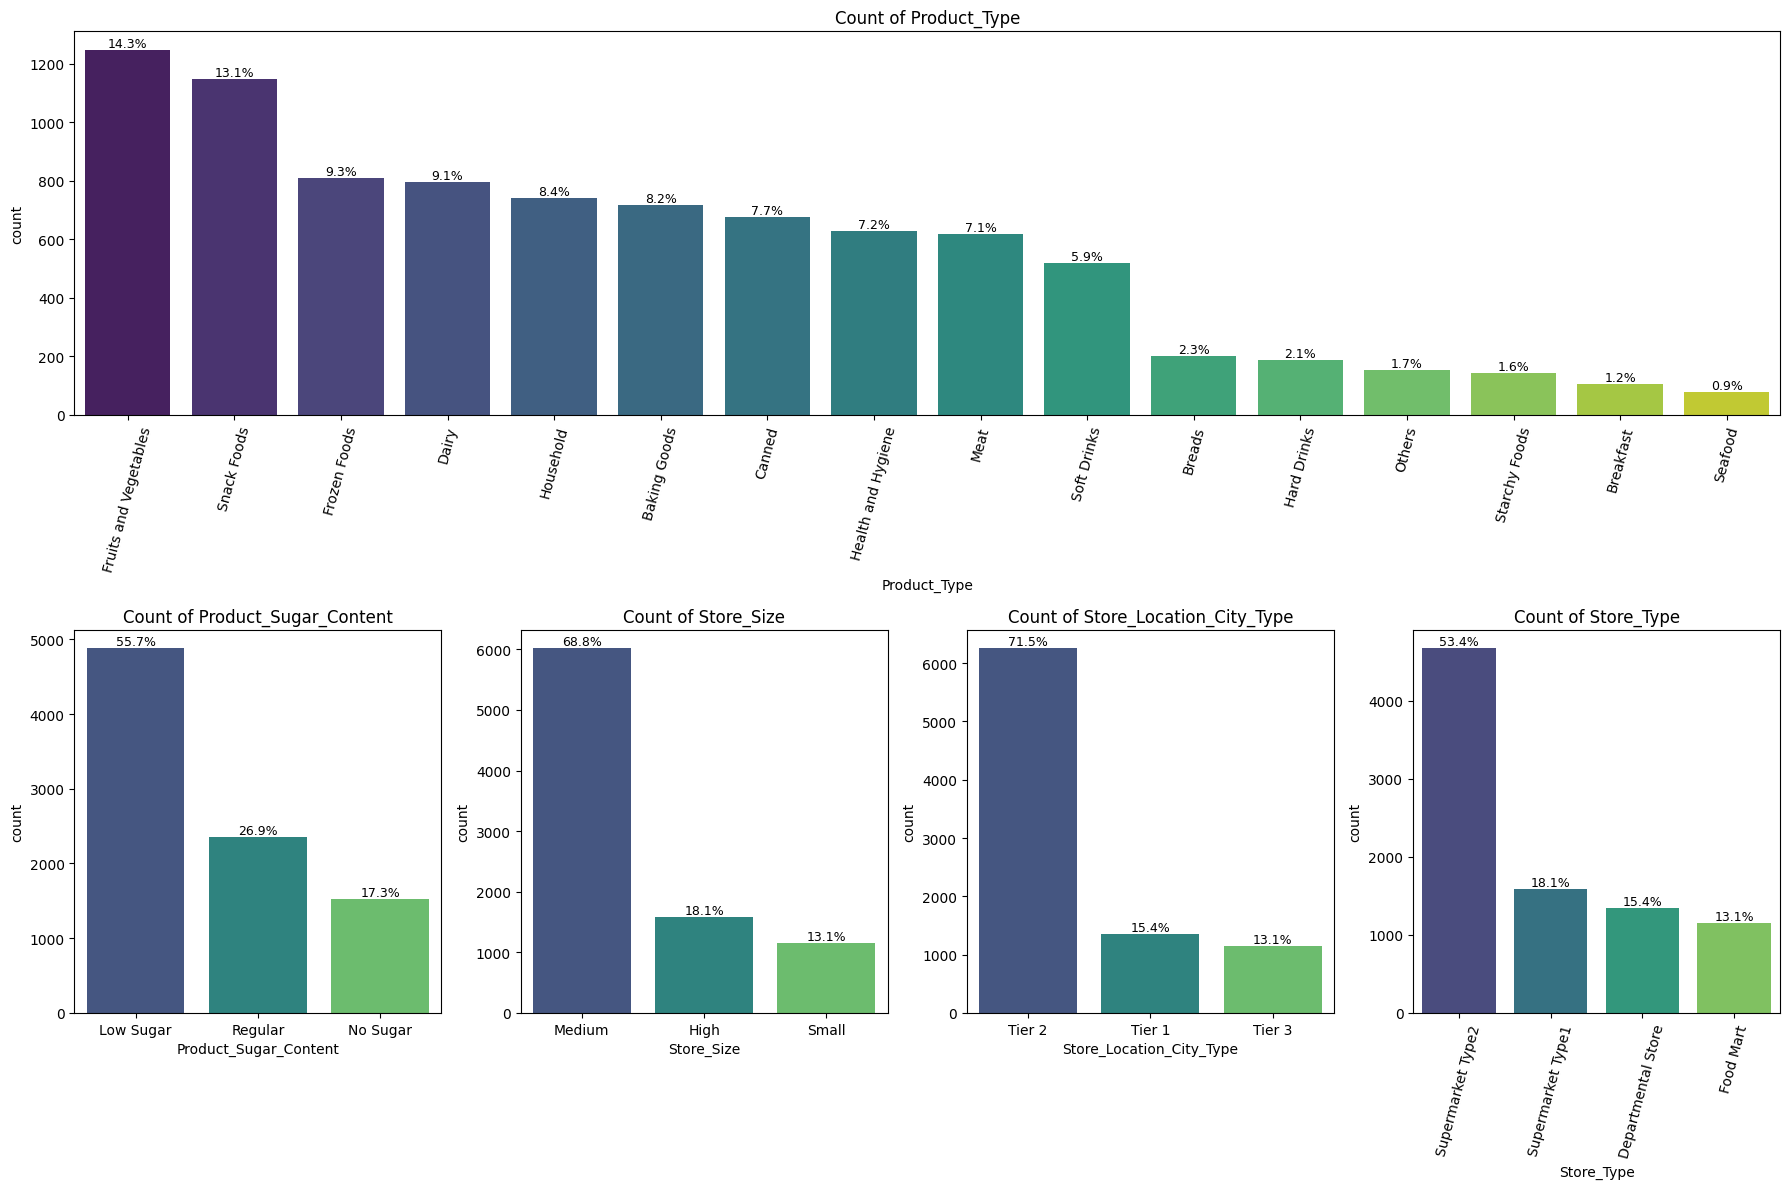

In [19]:
def labeled_barplot(data, feature, ax, rotate=False):
    """Countplot with percentage labels on each bar."""
    order = data[feature].value_counts().index
    sns.countplot(data=data, x=feature, order=order, ax=ax, palette="viridis")
    total = len(data)
    for p in ax.patches:
        ax.annotate(f"{100 * p.get_height() / total:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Count of {feature}")
    if rotate:
        ax.tick_params(axis="x", rotation=75)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 4)
labeled_barplot(df, "Product_Type", fig.add_subplot(gs[0, :]), rotate=True)
for i, col in enumerate(["Product_Sugar_Content", "Store_Size", "Store_Location_City_Type", "Store_Type"]):
    labeled_barplot(df, col, fig.add_subplot(gs[1, i]), rotate=(col == "Store_Type"))
plt.tight_layout()
plt.show()

**Observations:**
- **Product_Sugar_Content:** Low Sugar products dominate (~56%), followed by Regular (~27%) and No Sugar (~17%).
- **Product_Type:** Fruits and Vegetables (~14%) and Snack Foods (~13%) are the most common categories; Seafood, Breakfast, Starchy Foods and Others are the rarest (< 2% each).
- **Store_Size:** Medium stores account for ~69% of rows (OUT003 + OUT004).
- **Store_Location_City_Type:** Tier 2 cities account for ~71% of rows.
- **Store_Type:** Supermarket Type2 (single store OUT004) alone contributes ~53% of rows - the data is heavily imbalanced towards one store.

## Bivariate Analysis

### Numerical features vs. target

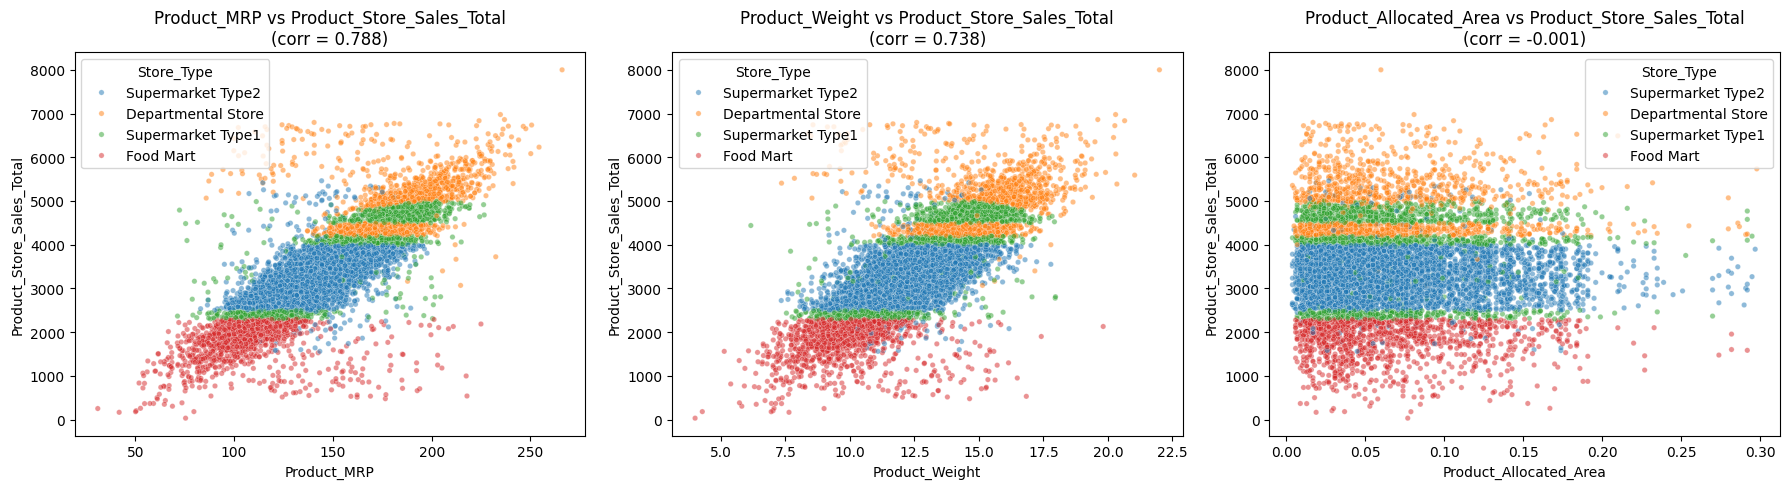

In [20]:
target = "Product_Store_Sales_Total"
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Product_MRP", "Product_Weight", "Product_Allocated_Area"]):
    sns.scatterplot(data=df, x=col, y=target, hue="Store_Type", alpha=0.5, s=15, ax=ax)
    ax.set_title(f"{col} vs {target}\n(corr = {df[col].corr(df[target]):.3f})")
plt.tight_layout()
plt.show()

### Target by store attributes

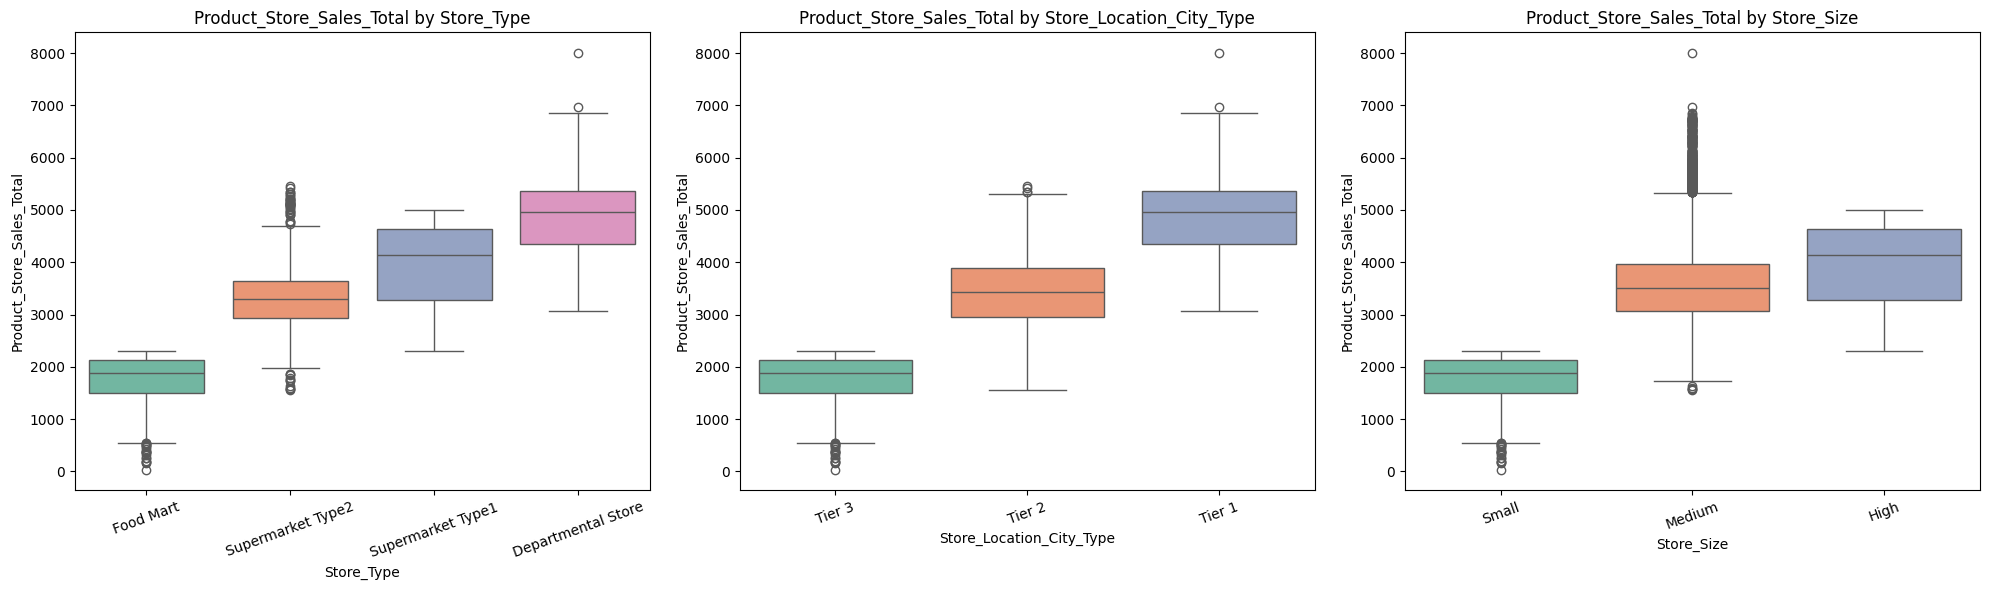

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col in zip(axes, ["Store_Type", "Store_Location_City_Type", "Store_Size"]):
    order = df.groupby(col)[target].median().sort_values().index
    sns.boxplot(data=df, x=col, y=target, order=order, ax=ax, palette="Set2")
    ax.set_title(f"{target} by {col}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [22]:
# Average and total revenue by store attributes
for col in ["Store_Type", "Store_Location_City_Type", "Store_Size"]:
    summary = df.groupby(col)[target].agg(["count", "mean", "median", "sum"])
    summary["share_of_revenue_%"] = (summary["sum"] / summary["sum"].sum() * 100).round(2)
    print(f"--- {col} ---")
    print(summary.sort_values("mean", ascending=False), "\n")

--- Store_Type ---
                    count      mean    median            sum  \
Store_Type                                                     
Departmental Store   1349 4,946.966 4,958.290  6,673,457.570   
Supermarket Type1    1586 3,923.779 4,139.645  6,223,113.180   
Supermarket Type2    4676 3,299.312 3,304.180 15,427,583.430   
Food Mart            1152 1,762.942 1,889.495  2,030,909.720   

                    share_of_revenue_%  
Store_Type                              
Departmental Store              21.980  
Supermarket Type1               20.500  
Supermarket Type2               50.820  
Food Mart                        6.690   

--- Store_Location_City_Type ---
                          count      mean    median            sum  \
Store_Location_City_Type                                             
Tier 1                     1349 4,946.966 4,958.290  6,673,457.570   
Tier 2                     6262 3,457.473 3,426.830 21,650,696.610   
Tier 3                     1152 1,7

### Target by product attributes

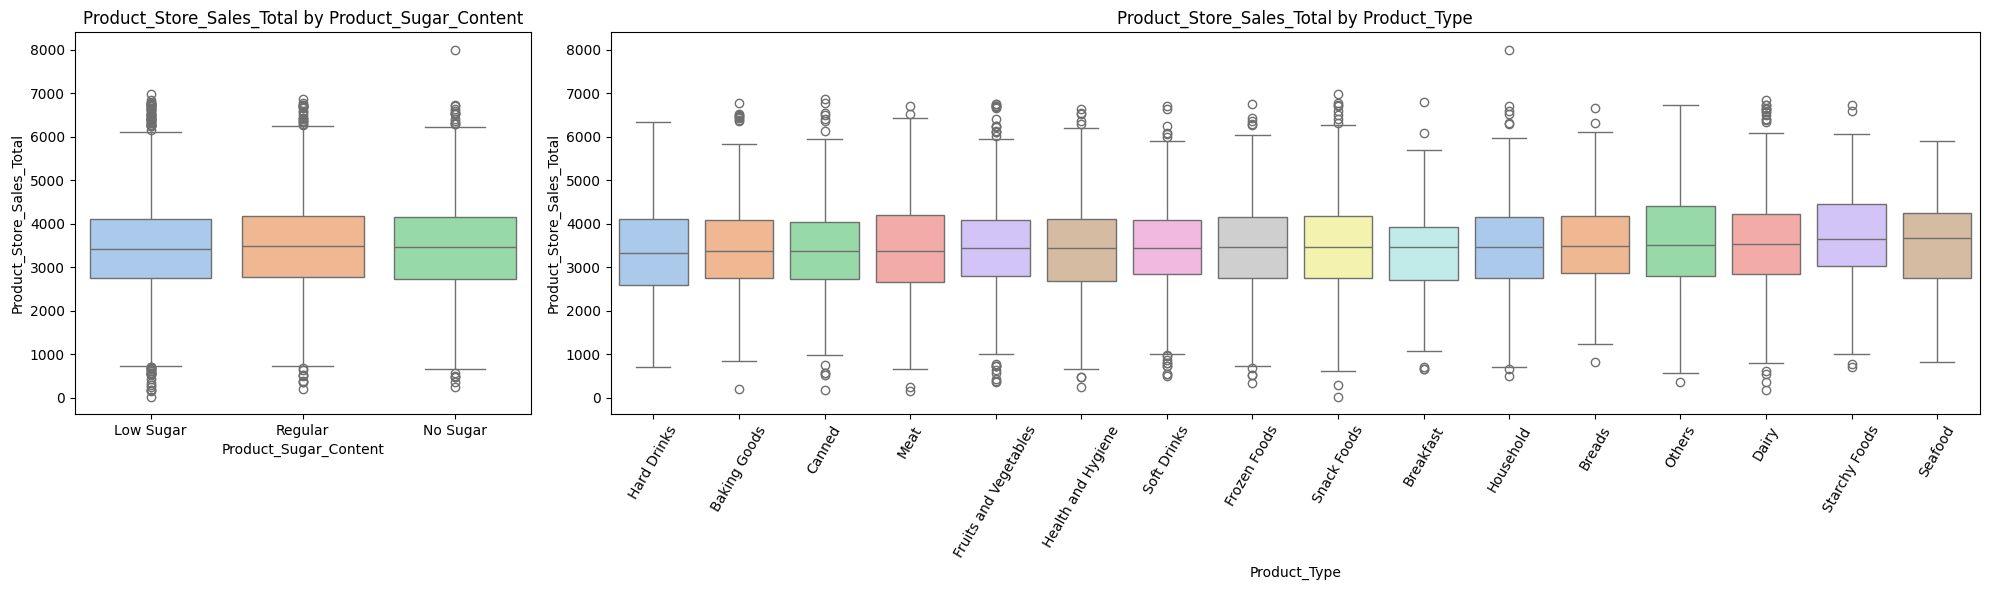

,count,mean,sum
Product_Type,,,
Fruits and Vegetables,1249,"3,443.421","4,300,833.270"
Snack Foods,1149,"3,471.712","3,988,996.950"
Dairy,796,"3,532.560","2,811,918.040"
Frozen Foods,811,"3,464.835","2,809,980.830"
Household,740,"3,465.865","2,564,740.170"
Baking Goods,716,"3,425.958","2,452,986.000"
Canned,677,"3,397.463","2,300,082.710"
Health and Hygiene,628,"3,445.394","2,163,707.210"
Meat,618,"3,445.327","2,129,211.940"


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={"width_ratios": [1, 3]})
sns.boxplot(data=df, x="Product_Sugar_Content", y=target, ax=axes[0], palette="pastel")
axes[0].set_title(f"{target} by Product_Sugar_Content")
order = df.groupby("Product_Type")[target].median().sort_values().index
sns.boxplot(data=df, x="Product_Type", y=target, order=order, ax=axes[1], palette="pastel")
axes[1].set_title(f"{target} by Product_Type")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

df.groupby("Product_Type")[target].agg(["count", "mean", "sum"]).sort_values("sum", ascending=False)

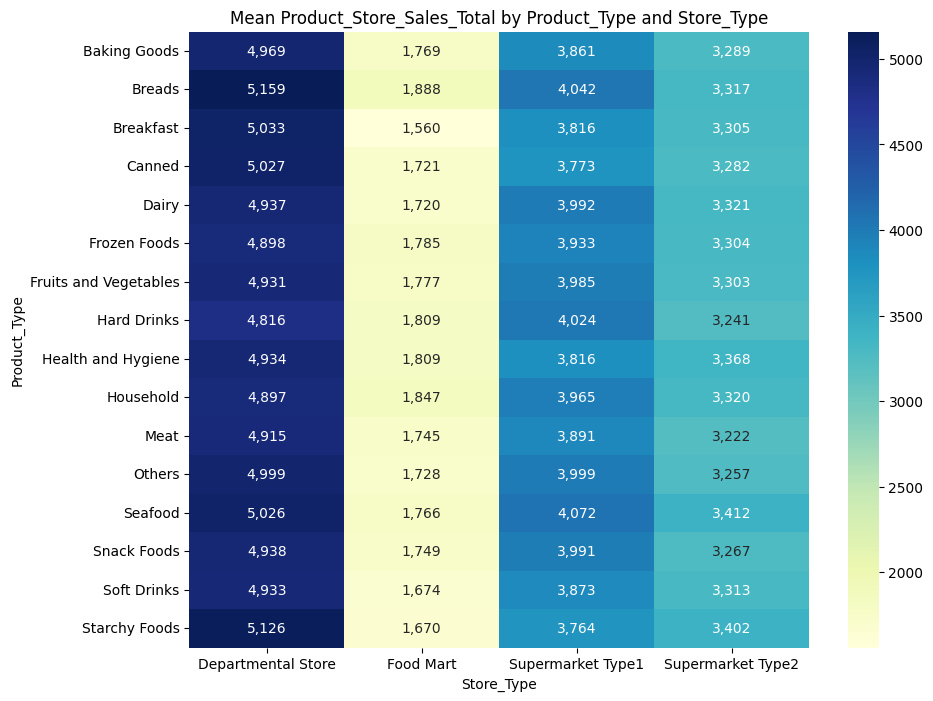

In [24]:
# Revenue by store type and product type (mean sales)
pivot = df.pivot_table(index="Product_Type", columns="Store_Type", values=target, aggfunc="mean")
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu")
plt.title("Mean Product_Store_Sales_Total by Product_Type and Store_Type")
plt.show()

### Correlation heatmap

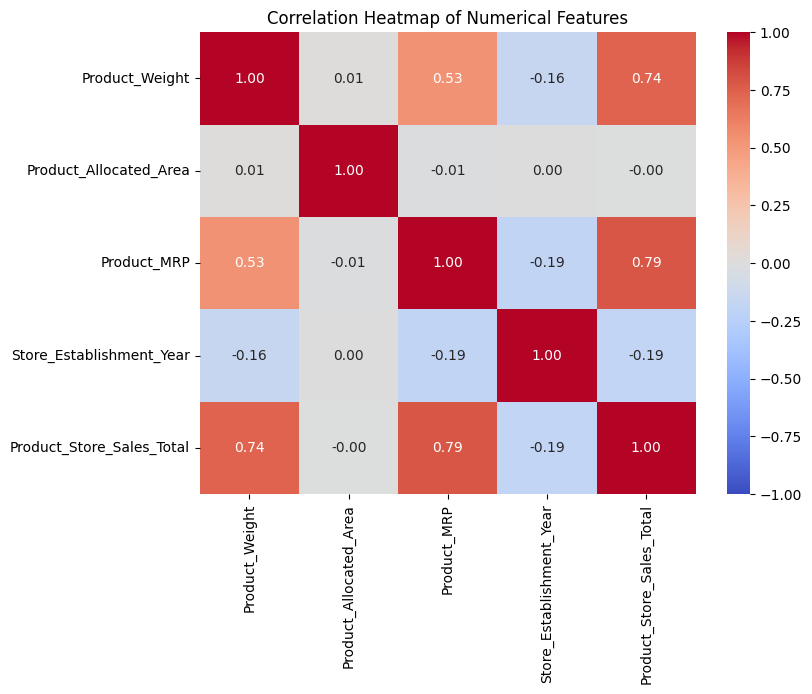

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Observations:**
- **Product_MRP** has the strongest linear relationship with sales (corr ~0.79): higher-priced products generate more revenue per product-store.
- **Product_Weight** is also strongly correlated with sales (~0.74) and moderately correlated with MRP (~0.53) - heavier products tend to be priced higher.
- **Product_Allocated_Area** shows essentially **no correlation** with sales (~0.00): more shelf space does not by itself translate into higher revenue.
- **Store_Type** is a strong differentiator: Departmental Store (OUT003, Tier 1) has the highest average sales (~4,947), followed by Supermarket Type1 (~3,924), Supermarket Type2 (~3,299) and Food Mart (~1,763).
- **City tier:** Tier 1 > Tier 2 > Tier 3 on average sales per product; Tier 3 (Food Mart only) earns about one third of Tier 1 per product.
- **Store size:** Small stores have the lowest sales; High and Medium stores perform far better on average.
- Supermarket Type2 has the lowest-but-one average per product, yet contributes **~51% of total revenue** because it stocks the largest number of products.
- **Product_Type** and **Product_Sugar_Content** show very similar median sales across categories - they are weak individual predictors compared to store attributes, MRP and weight.

# **5. Data Preprocessing**

## Feature Engineering

- **Product_Id_char**: the first two letters of `Product_Id` (FD = Food, DR = Drinks, NC = Non-Consumables). The full ID is unique per row and useless for modelling, but the prefix carries product-group information.
- **Store_Age_Years** = 2024 - `Store_Establishment_Year`: age is more interpretable and generalises better than a raw year.
- **Product_Type_Category**: groups the 16 product types into *Perishables* and *Non Perishables*, reducing cardinality while retaining a meaningful business distinction.

In [26]:
# 1. Product prefix
df["Product_Id_char"] = df["Product_Id"].str[:2]

# 2. Store age
df["Store_Age_Years"] = 2024 - df["Store_Establishment_Year"]

# 3. Perishable / non-perishable grouping (labels match the values present in the data, e.g. "Breads")
perishables = ["Dairy", "Meat", "Seafood", "Fruits and Vegetables", "Breakfast", "Frozen Foods", "Baking Goods", "Breads"]
non_perishables = ["Snack Foods", "Hard Drinks", "Soft Drinks", "Canned", "Starchy Foods", "Household", "Health and Hygiene", "Others"]
category_map = {**{t: "Perishables" for t in perishables}, **{t: "Non Perishables" for t in non_perishables}}
df["Product_Type_Category"] = df["Product_Type"].map(category_map)

# Sanity check: every product type was mapped
assert df["Product_Type_Category"].isin(["Perishables", "Non Perishables"]).all()

print(df["Product_Id_char"].value_counts(), "\n")
print(df["Store_Age_Years"].value_counts(), "\n")
print(df["Product_Type_Category"].value_counts())

Product_Id_char
FD    6539
NC    1519
DR     705
Name: count, dtype: int64 

Store_Age_Years
15    4676
37    1586
25    1349
26    1152
Name: count, dtype: int64 

Product_Type_Category
Perishables        4572
Non Perishables    4191
Name: count, dtype: int64


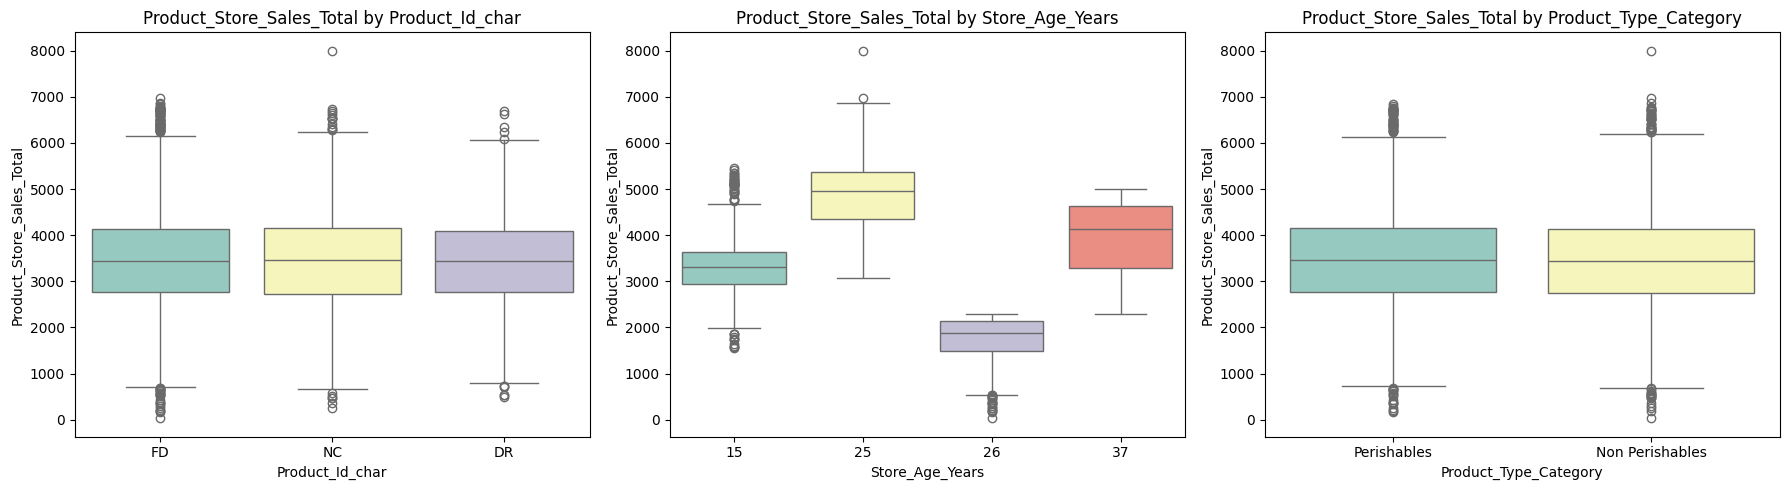

In [27]:
# Do the engineered features relate to sales?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Product_Id_char", "Store_Age_Years", "Product_Type_Category"]):
    sns.boxplot(data=df, x=col, y=target, ax=ax, palette="Set3")
    ax.set_title(f"{target} by {col}")
plt.tight_layout()
plt.show()

In [28]:
# Drop identifiers and columns replaced by engineered features
df = df.drop(columns=["Product_Id", "Store_Id", "Store_Establishment_Year", "Product_Type"])
df.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.660,Low Sugar,0.027,117.080,Medium,Tier 2,Supermarket Type2,"2,842.400",FD,15,Perishables
1,16.540,Low Sugar,0.144,171.430,Medium,Tier 1,Departmental Store,"4,830.020",FD,25,Perishables
2,14.280,Regular,0.031,162.080,High,Tier 2,Supermarket Type1,"4,130.160",FD,37,Non Perishables
3,12.100,Low Sugar,0.112,186.310,High,Tier 2,Supermarket Type1,"4,132.180",FD,37,Perishables
4,9.570,No Sugar,0.010,123.670,Small,Tier 3,Food Mart,"2,279.360",NC,26,Non Perishables


**Observations:** Drinks (DR) and Non-Consumables (NC) have slightly different sales profiles from Food (FD). Store age shows a clear non-monotonic pattern (it mirrors the store identity: 25-year-old OUT003 is the best performer, 26-year-old OUT002 the weakest), which tree-based models can capture. Perishables vs Non Perishables show similar distributions.

## Missing Value Treatment

In [29]:
print("Missing values before treatment:")
print(df[["Product_Weight", "Store_Size"]].isnull().sum())

# Product_Weight: median within each product group (FD / DR / NC)
df["Product_Weight"] = df["Product_Weight"].fillna(df.groupby("Product_Id_char")["Product_Weight"].transform("median"))

# Store_Size: mode
df["Store_Size"] = df["Store_Size"].fillna(df["Store_Size"].mode()[0])

print("\nMissing values after treatment:")
print(df.isnull().sum())

Missing values before treatment:
Product_Weight    0
Store_Size        0
dtype: int64

Missing values after treatment:
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_MRP                  0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
Product_Id_char              0
Store_Age_Years              0
Product_Type_Category        0
dtype: int64


**Observation:** The dataset has **no missing values**, so the group-median (Product_Weight) and mode (Store_Size) imputations above are no-ops on this data. They are kept as a safeguard, and the model pipeline additionally contains `SimpleImputer` steps so that any missing values arriving at **inference time** (API / batch files) are handled automatically.

## Outlier Detection and Treatment

In [30]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return lower, upper, ((series < lower) | (series > upper)).sum()

rows = []
for col in num_cols + ["Store_Age_Years"]:
    lower, upper, n = iqr_outliers(df[col])
    rows.append({"Column": col, "Lower bound": lower, "Upper bound": upper, "Outliers": n, "Outlier %": round(n / len(df) * 100, 2)})
outlier_summary = pd.DataFrame(rows)
outlier_summary

,Column,Lower bound,Upper bound,Outliers,Outlier %
0,Product_Weight,6.605,18.725,54,0.620
1,Product_Allocated_Area,-0.067,0.194,104,1.190
2,Product_MRP,64.022,229.723,57,0.650
3,Product_Store_Sales_Total,686.540,"6,220.340",119,1.360
4,Store_Age_Years,-1.500,42.500,0,0.000


**Rationale for treatment:**
- Outliers are a small share of each column (~0.6-1.4%) and are plausible values (no negative weights/prices), so **rows are not removed** - deleting them would lose real information.
- The **input features** `Product_Weight`, `Product_Allocated_Area` and `Product_MRP` are **capped (Winsorised) at the 1.5 x IQR fences** to limit the influence of extreme values.
- **The target `Product_Store_Sales_Total` is not capped**: altering the target would bias the model towards under-predicting genuine high-revenue product-store combinations, which matter most for the business.
- `Store_Age_Years` has only 4 distinct values and no outliers.
- **No leakage / production-safe:** the IQR fences are computed **on the training set only (after the split)** and capping is implemented as a step **inside the model pipeline** (`FunctionTransformer` with `np.clip`). The same training-set bounds are therefore applied to the test set and to every API request, without any extra code in the deployed app.

## Train-Test Split

In [31]:
numeric_features = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Age_Years"]
categorical_features = ["Product_Sugar_Content", "Store_Size", "Store_Location_City_Type", "Store_Type",
                        "Product_Id_char", "Product_Type_Category"]

features = ["Product_Weight", "Product_Sugar_Content", "Product_Allocated_Area", "Product_MRP", "Store_Size",
            "Store_Location_City_Type", "Store_Type", "Product_Id_char", "Store_Age_Years", "Product_Type_Category"]

X = df[features]
y = df["Product_Store_Sales_Total"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train mean: {:,.2f} | y_test mean: {:,.2f}".format(y_train.mean(), y_test.mean()))

X_train: (7010, 10) | X_test: (1753, 10)
y_train mean: 3,464.67 | y_test mean: 3,461.34


In [32]:
# IQR capping bounds computed on TRAINING data only
cap_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP"]
q1, q3 = X_train[numeric_features].quantile(0.25), X_train[numeric_features].quantile(0.75)
iqr = q3 - q1
lower_bounds = (q1 - 1.5 * iqr)
upper_bounds = (q3 + 1.5 * iqr)
# Store_Age_Years is not capped (only 4 values) -> use infinite bounds
lower_bounds["Store_Age_Years"], upper_bounds["Store_Age_Years"] = -np.inf, np.inf

cap_bounds = pd.DataFrame({"lower": lower_bounds, "upper": upper_bounds})
print(cap_bounds)

n_capped = ((X_train[numeric_features] < lower_bounds) | (X_train[numeric_features] > upper_bounds)).sum()
print("\nTraining values that will be capped per column:")
print(n_capped)

                        lower   upper
Product_Weight          6.620  18.700
Product_Allocated_Area -0.067   0.194
Product_MRP            64.299 229.429
Store_Age_Years          -inf     inf

Training values that will be capped per column:
Product_Weight            38
Product_Allocated_Area    81
Product_MRP               47
Store_Age_Years            0
dtype: int64


## Preprocessing Pipeline

- **Numerical features:** `SimpleImputer(median)` -> IQR capping (`np.clip` with training bounds) -> `StandardScaler`.
- **Categorical features:** `SimpleImputer(most_frequent)` -> `OneHotEncoder(handle_unknown="ignore")`.
  - One-hot encoding is used because the categories are nominal (or have few levels), and `handle_unknown="ignore"` makes the deployed model robust to **unseen categories** (e.g. the batch file contains `Supermarket Type3`, which does not exist in the training data).
- The combined `ColumnTransformer` is the `preprocessor` used inside every model pipeline, so the same transformations are applied during training, evaluation and deployment.

In [33]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("capper", FunctionTransformer(np.clip, kw_args={"a_min": lower_bounds[numeric_features].values,
                                                     "a_max": upper_bounds[numeric_features].values},
                                 feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# Quick check of the transformed training matrix
Xt = preprocessor.fit_transform(X_train)
print("Transformed training shape:", Xt.shape)
print("Feature names:", list(preprocessor.get_feature_names_out()))
print("Capped max values (scaled back check):",
      dict(zip(cap_cols, np.clip(X_train[cap_cols].values, lower_bounds[cap_cols].values, upper_bounds[cap_cols].values).max(axis=0).round(3))))
preprocessor

Transformed training shape: (7010, 22)
Feature names: ['num__Product_Weight', 'num__Product_Allocated_Area', 'num__Product_MRP', 'num__Store_Age_Years', 'cat__Product_Sugar_Content_Low Sugar', 'cat__Product_Sugar_Content_No Sugar', 'cat__Product_Sugar_Content_Regular', 'cat__Store_Size_High', 'cat__Store_Size_Medium', 'cat__Store_Size_Small', 'cat__Store_Location_City_Type_Tier 1', 'cat__Store_Location_City_Type_Tier 2', 'cat__Store_Location_City_Type_Tier 3', 'cat__Store_Type_Departmental Store', 'cat__Store_Type_Food Mart', 'cat__Store_Type_Supermarket Type1', 'cat__Store_Type_Supermarket Type2', 'cat__Product_Id_char_DR', 'cat__Product_Id_char_FD', 'cat__Product_Id_char_NC', 'cat__Product_Type_Category_Non Perishables', 'cat__Product_Type_Category_Perishables']
Capped max values (scaled back check): {'Product_Weight': np.float64(18.7), 'Product_Allocated_Area': np.float64(0.194), 'Product_MRP': np.float64(229.429)}


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('capper',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<function clip at 0x73ec693f4630>,
                                                                      kw_args={'a_max': array([1.8700000e+01, 1.9350000e-01, 2.2942875e+02,           inf]),
                                                                               'a_min': array([ 6.62   , -0.0665 , 64.29875,     -inf])})),
                                                 ('scaler', StandardScaler())]),
                                 ['Product_Weight', 'Product_Allocated_Area',
                                  'Product_MRP', 'Store_Age_Years']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Product_Sugar_Content', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type',
                                  'Product_Id_char',
                                  'Product_Type_Category'])])

# **6. Model Building**

## Choice of evaluation metric

This is a **regression** problem (predicting revenue). The primary metric is **RMSE (Root Mean Squared Error) - lower is better**:
- It is expressed in the **same units as revenue**, so it is directly interpretable by the business ("on average our forecast is off by about X currency units").
- It **penalises large errors more heavily** than MAE. Large forecasting misses are the costliest for SuperKart (stock-outs on high-revenue items or heavy overstocking), so penalising them is desirable.

Supporting metrics: **R-squared** (share of variance explained), **Adjusted R-squared** (R-squared penalised for number of predictors), **MAE** and **MAPE** (percentage error, easy to communicate).

## Define functions for Model Evaluation

In [34]:
# function to compute adjusted R-squared
# k = number of predictors the estimator actually sees, i.e. the columns AFTER one-hot encoding
def adj_r2_score(model, predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    if hasattr(model, "named_steps") and "preprocessor" in model.named_steps:
        k = len(model.named_steps["preprocessor"].get_feature_names_out())
    else:
        k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Compute RMSE, MAE, R-squared, Adjusted R-squared and MAPE for a fitted regressor.

    model: fitted regressor / pipeline
    predictors: independent variables
    target: dependent variable
    """
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)
    adjr2 = adj_r2_score(model, predictors, target, pred)
    rmse = np.sqrt(mean_squared_error(target, pred))
    mae = mean_absolute_error(target, pred)
    mape = mean_absolute_percentage_error(target, pred)

    return pd.DataFrame(
        {"RMSE": rmse, "MAE": mae, "R-squared": r2, "Adj. R-squared": adjr2, "MAPE": mape},
        index=[0],
    )


def train_test_report(model, name):
    """Side-by-side train and test performance for a fitted model."""
    tr = model_performance_regression(model, X_train, y_train)
    te = model_performance_regression(model, X_test, y_test)
    out = pd.concat([tr, te]).T
    out.columns = ["Train", "Test"]
    print(f"===== {name} =====")
    return out

## Model 1: Random Forest Regressor

In [35]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])
rf_pipeline.fit(X_train, y_train)

rf_perf = train_test_report(rf_pipeline, "Random Forest (default)")
rf_perf

===== Random Forest (default) =====


,Train,Test
RMSE,107.540,286.834
MAE,40.685,109.686
R-squared,0.990,0.928
Adj. R-squared,0.990,0.927
MAPE,0.015,0.039


## Model 2: XGBoost Regressor

In [36]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])
xgb_pipeline.fit(X_train, y_train)

xgb_perf = train_test_report(xgb_pipeline, "XGBoost (default)")
xgb_perf

===== XGBoost (default) =====


,Train,Test
RMSE,131.917,302.457
MAE,61.808,134.126
R-squared,0.985,0.920
Adj. R-squared,0.985,0.919
MAPE,0.022,0.050


In [37]:
# Summary table of baseline models
baseline = pd.DataFrame({
    "Train RMSE": [rf_perf.loc["RMSE", "Train"], xgb_perf.loc["RMSE", "Train"]],
    "Test RMSE": [rf_perf.loc["RMSE", "Test"], xgb_perf.loc["RMSE", "Test"]],
    "Train R2": [rf_perf.loc["R-squared", "Train"], xgb_perf.loc["R-squared", "Train"]],
    "Test R2": [rf_perf.loc["R-squared", "Test"], xgb_perf.loc["R-squared", "Test"]],
}, index=["Random Forest", "XGBoost"])
baseline["RMSE gap (Test-Train)"] = baseline["Test RMSE"] - baseline["Train RMSE"]
baseline

,Train RMSE,Test RMSE,Train R2,Test R2,RMSE gap (Test-Train)
Random Forest,107.540,286.834,0.990,0.928,179.294
XGBoost,131.917,302.457,0.985,0.920,170.540



**Observations on baseline models:**
- Both models fit the data well: **Random Forest** reaches Test RMSE **286.83** (Test R² **0.928**, MAPE ~3.9%) and **XGBoost** Test RMSE **302.46** (Test R² **0.920**, MAPE ~5.0%). On an average sales value of ~3,464 this is a typical error of well under 10%.
- **No underfitting:** training R² is ~0.99 for both models.
- **Some overfitting:** train RMSE (107.5 RF / 131.9 XGB) is ~2.3-2.7x lower than test RMSE. The test R² is still very high, so the models generalise well, but there is room to regularise - addressed through hyperparameter tuning below.
- At baseline, Random Forest is slightly better than XGBoost on every test metric.


# **7. Model Performance Improvement - Hyperparameter Tuning**

`RandomizedSearchCV` samples 20 hyperparameter combinations per model and evaluates each with **5-fold cross-validation** on the training set using **`neg_root_mean_squared_error`**, i.e. directly optimising our metric of choice (RMSE). The test set is not touched during tuning.

## Tuning Random Forest

In [38]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    Pipeline(steps=[("preprocessor", preprocessor), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))]),
    param_distributions=rf_param_grid,
    n_iter=20, cv=5, scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train)

rf_tuned = rf_search.best_estimator_
print("Best parameters:", rf_search.best_params_)
print("Best CV RMSE   : {:,.2f}".format(-rf_search.best_score_))

rf_tuned_perf = train_test_report(rf_tuned, "Random Forest (tuned)")
rf_tuned_perf

Best parameters: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}
Best CV RMSE   : 311.77
===== Random Forest (tuned) =====


,Train,Test
RMSE,113.734,305.756
MAE,55.114,149.783
R-squared,0.989,0.918
Adj. R-squared,0.989,0.917
MAPE,0.022,0.057


## Tuning XGBoost

In [39]:
xgb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    Pipeline(steps=[("preprocessor", preprocessor), ("model", XGBRegressor(random_state=42, n_jobs=-1))]),
    param_distributions=xgb_param_grid,
    n_iter=20, cv=5, scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

xgb_tuned = xgb_search.best_estimator_
print("Best parameters:", xgb_search.best_params_)
print("Best CV RMSE   : {:,.2f}".format(-xgb_search.best_score_))

xgb_tuned_perf = train_test_report(xgb_tuned, "XGBoost (tuned)")
xgb_tuned_perf

Best parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Best CV RMSE   : 290.08
===== XGBoost (tuned) =====


,Train,Test
RMSE,180.454,288.797
MAE,70.872,118.779
R-squared,0.971,0.927
Adj. R-squared,0.971,0.926
MAPE,0.026,0.043



**Observations on tuned models:**
- **Tuned XGBoost** (200 trees, max_depth 7, learning_rate 0.05, subsample 1.0, colsample_bytree 1.0; CV RMSE 290.08) improved Test RMSE from 302.46 to **288.80** (~4.5% better) and Test R² from 0.920 to **0.927**. Its train RMSE rose to 180.45, so the train-test gap shrank from 170.5 to **108.3** - tuning made XGBoost clearly **less overfit and more stable**.
- **Tuned Random Forest** (200 trees, max_features='log2', no depth limit; CV RMSE 311.77) performed **worse** on the test set (305.76 vs 286.83 for the default). The search space only allowed `max_features` of 'sqrt'/'log2', whereas the default RF considers all features at every split. With 'log2', each split sees only ~4 of the 22 encoded columns, so the dominant predictors (Product_MRP, Product_Weight) are often unavailable - this restriction costs more accuracy than the extra trees gain.
- Tuning was guided purely by cross-validated RMSE on the training data, so the test set remained an unbiased hold-out.


# **8. Model Performance Comparison, Final Model Selection, and Serialization**

In [40]:
models = {
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "Tuned Random Forest": rf_tuned,
    "Tuned XGBoost": xgb_tuned,
}

rows = []
for name, m in models.items():
    tr = model_performance_regression(m, X_train, y_train).iloc[0]
    te = model_performance_regression(m, X_test, y_test).iloc[0]
    rows.append({"Model": name, "Train RMSE": tr["RMSE"], "Test RMSE": te["RMSE"], "Train R2": tr["R-squared"],
                 "Test R2": te["R-squared"], "Test Adj. R2": te["Adj. R-squared"], "Test MAE": te["MAE"],
                 "Test MAPE": te["MAPE"]})
comparison = pd.DataFrame(rows).set_index("Model")
comparison["RMSE gap (Test-Train)"] = comparison["Test RMSE"] - comparison["Train RMSE"]
comparison.sort_values("Test RMSE")

,Train RMSE,Test RMSE,Train R2,Test R2,Test Adj. R2,Test MAE,Test MAPE,RMSE gap (Test-Train)
Model,,,,,,,,
Random Forest,107.540,286.834,0.990,0.928,0.927,109.686,0.039,179.294
Tuned XGBoost,180.454,288.797,0.971,0.927,0.926,118.779,0.043,108.343
XGBoost,131.917,302.457,0.985,0.920,0.919,134.126,0.050,170.540
Tuned Random Forest,113.734,305.756,0.989,0.918,0.917,149.783,0.057,192.022


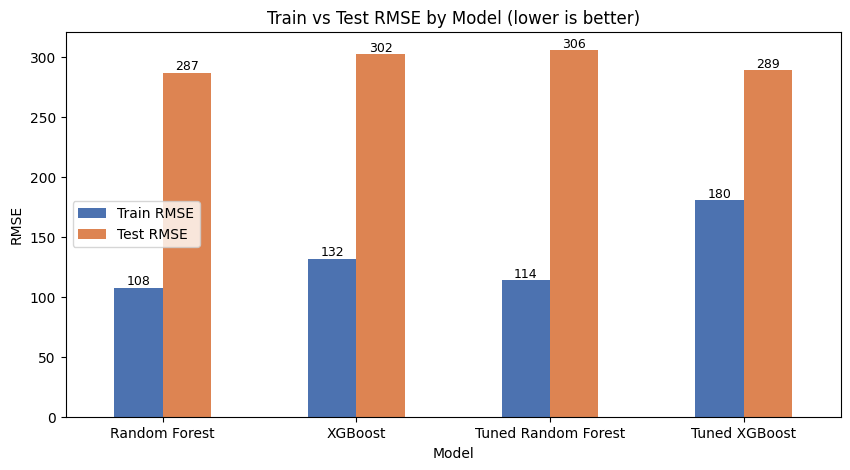

In [41]:
# Visual comparison of train vs test RMSE
ax = comparison[["Train RMSE", "Test RMSE"]].plot(kind="bar", figsize=(10, 5), color=["#4C72B0", "#DD8452"])
ax.set_title("Train vs Test RMSE by Model (lower is better)")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom", fontsize=9)
plt.show()

In [42]:
# Select the final model: lowest Test RMSE
best_model_name = comparison["Test RMSE"].idxmin()
best_model = models[best_model_name]
best = comparison.loc[best_model_name]

print(f"Best model          : {best_model_name}")
print(f"Test RMSE           : {best['Test RMSE']:,.2f}")
print(f"Test R2             : {best['Test R2']:.4f}")
print(f"Test MAPE           : {best['Test MAPE']:.2%}")
print(f"Train/Test RMSE gap : {best['RMSE gap (Test-Train)']:,.2f} "
      f"({best['RMSE gap (Test-Train)'] / best['Train RMSE']:.1%} of train RMSE)")
print(f"Train/Test R2 gap   : {best['Train R2'] - best['Test R2']:.4f}")

Best model          : Random Forest
Test RMSE           : 286.83
Test R2             : 0.9279
Test MAPE           : 3.93%
Train/Test RMSE gap : 179.29 (166.7% of train RMSE)
Train/Test R2 gap   : 0.0619


### Performance of the best model on the test set

In [43]:
best_test_perf = model_performance_regression(best_model, X_test, y_test)
best_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,286.834,109.686,0.928,0.927,0.039


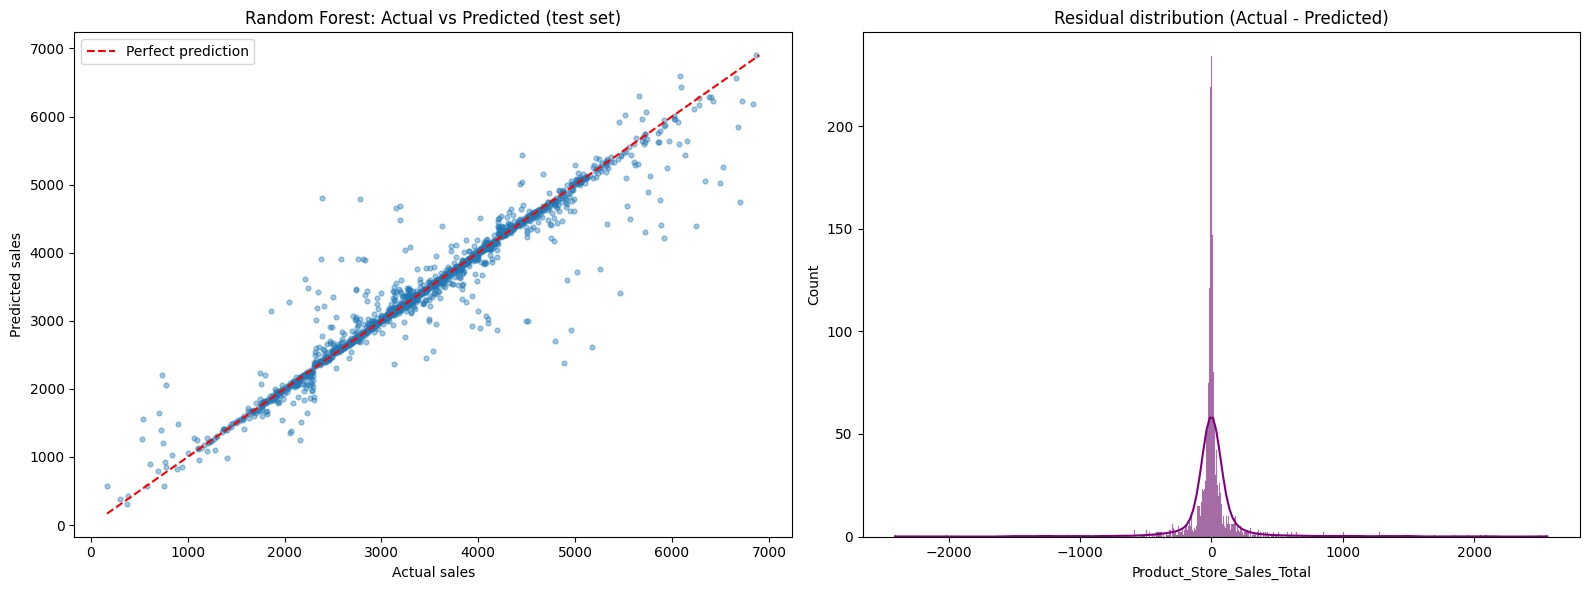

In [44]:
# Actual vs predicted on the test set, and residual distribution
test_pred = best_model.predict(X_test)
residuals = y_test - test_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(y_test, test_pred, alpha=0.4, s=12)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual sales"); axes[0].set_ylabel("Predicted sales")
axes[0].set_title(f"{best_model_name}: Actual vs Predicted (test set)")
axes[0].legend()
sns.histplot(residuals, kde=True, ax=axes[1], color="purple")
axes[1].set_title("Residual distribution (Actual - Predicted)")
plt.tight_layout()
plt.show()

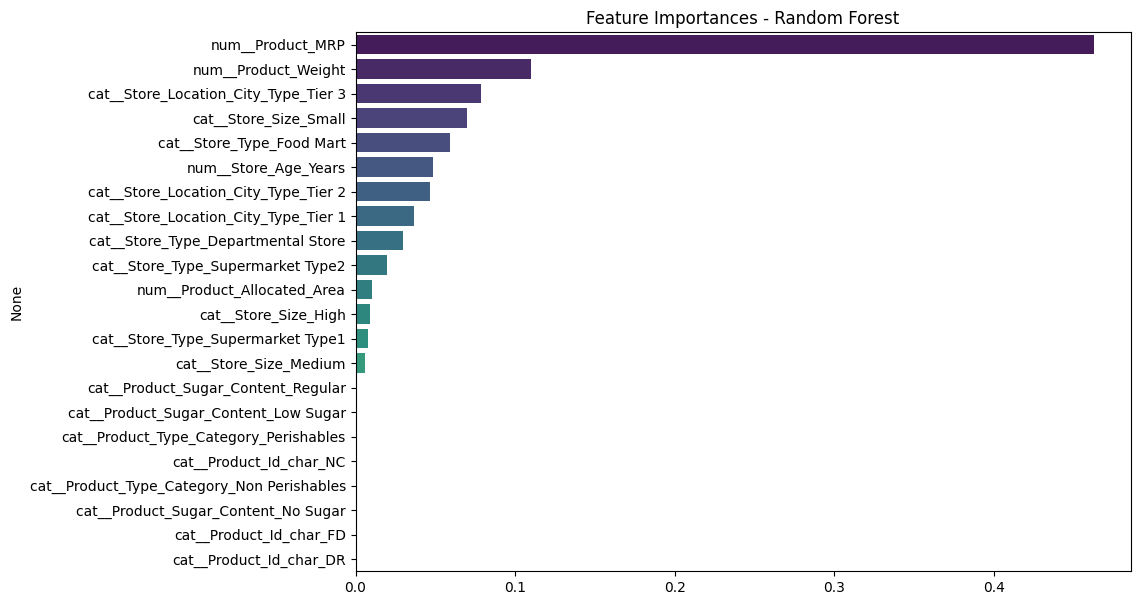

num__Product_MRP                       0.462
num__Product_Weight                    0.110
cat__Store_Location_City_Type_Tier 3   0.078
cat__Store_Size_Small                  0.070
cat__Store_Type_Food Mart              0.059
num__Store_Age_Years                   0.049
cat__Store_Location_City_Type_Tier 2   0.047
cat__Store_Location_City_Type_Tier 1   0.037
cat__Store_Type_Departmental Store     0.030
cat__Store_Type_Supermarket Type2      0.020
dtype: float64

In [45]:
# Feature importance of the best model
importances = pd.Series(best_model.named_steps["model"].feature_importances_,
                        index=best_model.named_steps["preprocessor"].get_feature_names_out()).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title(f"Feature Importances - {best_model_name}")
plt.show()
importances.head(10)


**Final model selection - rationale:**
- Using the agreed criterion (**lowest Test RMSE**), the **default Random Forest** is selected: Test RMSE **286.83**, Test MAE **109.69**, Test R² **0.928**, Test MAPE **3.93%**. It also has the best test MAE and MAPE of all four models.
- **Tuned XGBoost is a very close second** (Test RMSE 288.80, only ~0.7% higher) with a much smaller train-test gap (108 vs 179). The two are practically tied; Random Forest wins on all test error metrics, while Tuned XGBoost would be the preferred alternative if a smaller, more regularised model is required (the RF file is ~64 MB).
- **Overfitting check:** the selected RF has train RMSE 107.5 vs test RMSE 286.8 (R² 0.990 vs 0.928). There is a degree of overfitting (fully grown trees memorise training rows), but test performance remains strong and better than every more-regularised alternative, so the gap is acceptable for this use case.
- **Actual vs predicted** points lie tightly along the diagonal and residuals are centred on zero, with a handful of large misses.
- **Feature importance:** `Product_MRP` dominates (~46% of importance), followed by `Product_Weight` (~11%) and store-identity features (Tier 3 / Small / Food Mart, store age) - consistent with the EDA.


### Robustness check: generalisation to an unseen store

The random 80/20 split places rows from all 4 stores in both train and test, so the test score measures how well the model forecasts **new products in existing stores** - which is SuperKart's main use case. Because store attributes (type, size, tier, age) jointly identify each of the 4 stores, we also run a **leave-one-store-out** check (`GroupKFold` by `Store_Id`) to see how the model would behave for a store it has never seen.

In [46]:
from sklearn.model_selection import GroupKFold, cross_val_score

groups = data.loc[X.index, "Store_Id"]
gkf = GroupKFold(n_splits=4)
store_scores = -cross_val_score(best_model, X, y, groups=groups, cv=gkf,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
held_out = [groups.iloc[test_idx].unique()[0] for _, test_idx in gkf.split(X, y, groups)]
loso = pd.DataFrame({"Held-out store": held_out, "RMSE": store_scores}).set_index("Held-out store")
print(loso)
print(f"\nLeave-one-store-out mean RMSE: {store_scores.mean():,.2f}  vs  random-split test RMSE: {best['Test RMSE']:,.2f}")

                    RMSE
Held-out store          
OUT004         1,615.937
OUT001           934.208
OUT003         1,668.933
OUT002         2,567.333

Leave-one-store-out mean RMSE: 1,696.60  vs  random-split test RMSE: 286.83



**Observation:** When an entire store is held out, RMSE jumps to **934-2,567** (mean **~1,697**, about 6x the random-split test RMSE). The model is therefore **reliable for forecasting products in SuperKart's existing 4 stores/formats** - the business objective - but **should not be used to forecast a brand-new store or store format** (e.g. the `Supermarket Type3` rows in the batch file) until data from such stores is collected. The API flags such unseen categories with a warning.


## Serialize the best model

In [47]:
# Create a folder for the backend deployment files and save the model there and in the project folder
os.makedirs("backend_files", exist_ok=True)

model_path = "superkart_model.joblib"
joblib.dump(best_model, model_path)
joblib.dump(best_model, os.path.join("backend_files", model_path))
print(f"Model saved to {model_path} ({os.path.getsize(model_path) / 1e6:.2f} MB) and backend_files/{model_path}")

# Save a summary of all model metrics
metrics = {
    "primary_metric": "RMSE (lower is better)",
    "best_model": best_model_name,
    "best_model_params": {k: (v if isinstance(v, (int, float, str, type(None))) else str(v))
                          for k, v in best_model.named_steps["model"].get_params().items()
                          if k in ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf",
                                   "max_features", "learning_rate", "subsample", "colsample_bytree"]},
    "tuned_rf_best_params": rf_search.best_params_,
    "tuned_xgb_best_params": xgb_search.best_params_,
    "models": comparison.round(4).reset_index().to_dict(orient="records"),
}
with open("model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print("Metrics saved to model_metrics.json")

Model saved to superkart_model.joblib (63.82 MB) and backend_files/superkart_model.joblib
Metrics saved to model_metrics.json


## Load the serialized model and predict on the test set

In [48]:
loaded_model = joblib.load("superkart_model.joblib")
loaded_pred = loaded_model.predict(X_test)

# The loaded model must reproduce the in-memory model exactly
print("Predictions identical to in-memory model:", np.allclose(loaded_pred, best_model.predict(X_test)))
print("Loaded model test RMSE: {:,.2f}".format(np.sqrt(mean_squared_error(y_test, loaded_pred))))
print("Loaded model test R2  : {:.4f}".format(r2_score(y_test, loaded_pred)))

pd.DataFrame({"Actual": y_test.values[:5], "Predicted": loaded_pred[:5].round(2),
              "Difference": (y_test.values[:5] - loaded_pred[:5]).round(2)}, index=y_test.index[:5])

Predictions identical to in-memory model: True
Loaded model test RMSE: 286.83
Loaded model test R2  : 0.9279


,Actual,Predicted,Difference
1226,"3,396.370","3,395.050",1.320
7903,"3,371.450","3,364.730",6.720
1559,"2,416.690","2,454.280",-37.590
3621,"1,910.530","1,897.670",12.860
7552,"3,191.080","4,688.620","-1,497.540"


# **9. Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account (if you don't already have one) at [github.com](https://github.com) and generate a **Personal Access Token** with **repo** scope.
- The serialized model `superkart_model.joblib` has already been copied to the `backend_files` folder (see the serialization cell above).
- **Both the Flask backend and the Streamlit frontend are deployed as separate Docker containers inside a GitHub Codespace** and connected through a **Docker network**.

## Flask Web Framework

Flask is a lightweight Python web framework used to build web applications and REST APIs. Our API exposes two endpoints:
- `GET /` - health check
- `POST /v1/predict` - **online inference**: JSON body with one record, returns `{"prediction": value}`
- `POST /v1/predictbatch` - **batch inference**: CSV file upload (form field `file`), returns a JSON object mapping each row index to its predicted sales

In [49]:
os.makedirs("backend_files", exist_ok=True)

In [50]:
%%writefile backend_files/app.py
# SuperKart Sales Forecasting - Flask backend API
import joblib
import numpy as np
import pandas as pd
from flask import Flask, request, jsonify

# Initialise the Flask application
superkart_api = Flask("SuperKart Sales Predictor")

# Load the serialized pipeline (preprocessing + model) once at start-up
model = joblib.load("superkart_model.joblib")

# Category levels seen during training (used to flag unsupported inputs)
_cat = model.named_steps["preprocessor"].named_transformers_["cat"]
_cat_cols = model.named_steps["preprocessor"].transformers_[1][2]
KNOWN_LEVELS = {c: set(map(str, lv)) for c, lv in zip(_cat_cols, _cat.named_steps["encoder"].categories_)}

# Features expected by the model, in training order
FEATURES = [
    "Product_Weight", "Product_Sugar_Content", "Product_Allocated_Area", "Product_MRP",
    "Store_Size", "Store_Location_City_Type", "Store_Type", "Product_Id_char",
    "Store_Age_Years", "Product_Type_Category",
]
NUMERIC = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Age_Years"]


def prepare(df):
    """Validate columns and coerce types before prediction."""
    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required feature(s): {missing}")
    df = df[FEATURES].copy()
    for c in NUMERIC:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


@superkart_api.get("/")
def home():
    """Health check endpoint."""
    return "Welcome to the SuperKart Sales Prediction API!"


@superkart_api.post("/v1/predict")
def predict_sales():
    """Online inference: predict sales for a single product-store record sent as JSON."""
    try:
        data = request.get_json(force=True)
        sample = prepare(pd.DataFrame([data]))
        prediction = float(model.predict(sample)[0])
        result = {"prediction": round(prediction, 2)}
        # Flag categories not seen in training: the model still scores them, but they are unreliable
        unseen = {c: str(sample[c].iloc[0]) for c in KNOWN_LEVELS if str(sample[c].iloc[0]) not in KNOWN_LEVELS[c]}
        if unseen:
            result["warning"] = f"Unseen category value(s) {unseen}; prediction may be unreliable"
        return jsonify(result)
    except Exception as e:
        return jsonify({"error": str(e)}), 400


@superkart_api.post("/v1/predictbatch")
def predict_sales_batch():
    """Batch inference: predict sales for every row of an uploaded CSV file."""
    try:
        file = request.files.get("file")
        if file is None:
            return jsonify({"error": "No CSV file uploaded under form field 'file'"}), 400
        batch = prepare(pd.read_csv(file))
        predictions = np.round(model.predict(batch).astype(float), 2)
        # {row_index: predicted_sales}
        return jsonify({str(i): float(p) for i, p in zip(batch.index, predictions)})
    except Exception as e:
        return jsonify({"error": str(e)}), 400


if __name__ == "__main__":
    superkart_api.run(host="0.0.0.0", port=7860, debug=False)

Overwriting backend_files/app.py


## Dependencies File

In [51]:
%%writefile backend_files/requirements.txt
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
flask==3.1.0
gunicorn==23.0.0
requests==2.32.4

Overwriting backend_files/requirements.txt


## Dockerfile

The library versions match those used to train and serialize the model, which is required for `joblib.load` to work reliably. The container listens on port **7860**; Flask is served by **gunicorn** (a production WSGI server) bound to `0.0.0.0:7860`.

In [52]:
%%writefile backend_files/Dockerfile
# Lightweight Python base image
FROM python:3.11-slim

# Working directory inside the container
WORKDIR /app

# Install dependencies first (better layer caching)
COPY requirements.txt .
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Copy the API code and the serialized model
COPY . .

# Port on which the Flask API is served
EXPOSE 7860

# Run the Flask app (object `superkart_api` in app.py) on 0.0.0.0:7860 with gunicorn
CMD ["gunicorn", "-w", "2", "-b", "0.0.0.0:7860", "app:superkart_api"]

Overwriting backend_files/Dockerfile


In [53]:
# Files ready in the backend folder
for f in sorted(os.listdir("backend_files")):
    print(f"{f:28s} {os.path.getsize(os.path.join('backend_files', f)):>10,} bytes")

Dockerfile                          512 bytes
app.py                            3,025 bytes
requirements.txt                    123 bytes
superkart_model.joblib       63,816,467 bytes


# **10. Deployment - Frontend**

## Streamlit for Interactive UI

Streamlit turns a Python script into an interactive web app. The frontend has two tabs:
- **Single Prediction** - form inputs for every feature; calls `POST /v1/predict`
- **Batch Prediction** - CSV uploader; calls `POST /v1/predictbatch` and displays/downloads the results

The backend URL is read from the `BACKEND_URL` environment variable (default `http://superkart-backend:7860`, the backend container's name on the shared Docker network) and can be overridden in the sidebar.

In [54]:
os.makedirs("frontend_files", exist_ok=True)

In [55]:
%%writefile frontend_files/streamlit_app.py
# SuperKart Sales Forecasting - Streamlit frontend
import os
import requests
import pandas as pd
import streamlit as st

st.set_page_config(page_title="SuperKart Sales Predictor", page_icon="🛒", layout="wide")
st.title("SuperKart Sales Predictor")
st.write("Forecast the total sales revenue of a product in a SuperKart store.")

# Backend URL: environment variable, overridable from the sidebar
default_url = os.getenv("BACKEND_URL", "http://superkart-backend:7860")
BACKEND_URL = st.sidebar.text_input("Backend API URL", value=default_url).rstrip("/")
st.sidebar.caption("Inside the Codespace Docker network use http://superkart-backend:7860; "
                   "from outside use the forwarded port-7860 URL.")

tab_single, tab_batch = st.tabs(["Single Prediction", "Batch Prediction"])

# ---------------- Single prediction ----------------
with tab_single:
    st.subheader("Product details")
    c1, c2 = st.columns(2)
    with c1:
        product_weight = st.number_input("Product Weight", min_value=0.0, max_value=50.0, value=12.66, step=0.01)
        product_sugar = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
        product_area = st.number_input("Product Allocated Area (ratio)", min_value=0.0, max_value=1.0,
                                       value=0.027, step=0.001, format="%.3f")
        product_mrp = st.number_input("Product MRP", min_value=0.0, max_value=1000.0, value=117.08, step=0.01)
        product_id_char = st.selectbox("Product Id prefix", ["FD", "DR", "NC"],
                                       help="FD = Food, DR = Drinks, NC = Non-Consumables")
    with c2:
        product_category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])
        store_size = st.selectbox("Store Size", ["Small", "Medium", "High"], index=1)
        store_city = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"], index=1)
        store_type = st.selectbox("Store Type", ["Departmental Store", "Supermarket Type1",
                                                 "Supermarket Type2", "Food Mart"], index=2)
        store_age = st.number_input("Store Age (years)", min_value=0, max_value=100, value=16, step=1)

    payload = {
        "Product_Weight": product_weight,
        "Product_Sugar_Content": product_sugar,
        "Product_Allocated_Area": product_area,
        "Product_MRP": product_mrp,
        "Store_Size": store_size,
        "Store_Location_City_Type": store_city,
        "Store_Type": store_type,
        "Product_Id_char": product_id_char,
        "Store_Age_Years": int(store_age),
        "Product_Type_Category": product_category,
    }

    if st.button("Predict Sales", type="primary"):
        try:
            resp = requests.post(f"{BACKEND_URL}/v1/predict", json=payload, timeout=30)
            if resp.status_code == 200:
                st.success(f"Predicted Product Store Sales Total: **{resp.json()['prediction']:,.2f}**")
            else:
                st.error(f"API error ({resp.status_code}): {resp.text}")
        except requests.exceptions.RequestException as e:
            st.error(f"Could not reach the backend at {BACKEND_URL}: {e}")

# ---------------- Batch prediction ----------------
with tab_batch:
    st.subheader("Upload a CSV file")
    st.caption("Required columns: Product_Weight, Product_Sugar_Content, Product_Allocated_Area, Product_MRP, "
               "Store_Size, Store_Location_City_Type, Store_Type, Product_Id_char, Store_Age_Years, "
               "Product_Type_Category")
    uploaded = st.file_uploader("Choose a CSV file", type=["csv"])
    if uploaded is not None:
        batch_df = pd.read_csv(uploaded)
        st.write("Preview:", batch_df.head())
        if st.button("Predict Batch", type="primary"):
            try:
                files = {"file": ("batch.csv", batch_df.to_csv(index=False).encode("utf-8"), "text/csv")}
                resp = requests.post(f"{BACKEND_URL}/v1/predictbatch", files=files, timeout=120)
                if resp.status_code == 200:
                    preds = resp.json()
                    result = batch_df.copy()
                    result["Predicted_Sales"] = [preds[str(i)] for i in range(len(batch_df))]
                    st.success(f"Predicted {len(result)} rows.")
                    st.dataframe(result)
                    st.download_button("Download predictions", result.to_csv(index=False).encode("utf-8"),
                                       "superkart_predictions.csv", "text/csv")
                else:
                    st.error(f"API error ({resp.status_code}): {resp.text}")
            except requests.exceptions.RequestException as e:
                st.error(f"Could not reach the backend at {BACKEND_URL}: {e}")

Overwriting frontend_files/streamlit_app.py


## Dependencies File

In [56]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.32.4
streamlit==1.43.2

Overwriting frontend_files/requirements.txt


## Dockerfile

In [57]:
%%writefile frontend_files/Dockerfile
# Lightweight Python base image
FROM python:3.11-slim

WORKDIR /app

# Install dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Copy the Streamlit app
COPY . .

# Default backend address on the shared Docker network (can be overridden with -e BACKEND_URL=...)
ENV BACKEND_URL=http://superkart-backend:7860

# Streamlit port
EXPOSE 8501

CMD ["streamlit", "run", "streamlit_app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Overwriting frontend_files/Dockerfile


In [58]:
for f in sorted(os.listdir("frontend_files")):
    print(f"{f:28s} {os.path.getsize(os.path.join('frontend_files', f)):>10,} bytes")

Dockerfile                          523 bytes
requirements.txt                     49 bytes
streamlit_app.py                  4,760 bytes


# **11. Pushing Deployment Files to GitHub**

The deployment files are organised into two folders, which are pushed to a single GitHub repository. The Codespace is then launched from that repository.

```
superkart-sales-forecasting/
├── backend_files/
│   ├── app.py
│   ├── superkart_model.joblib
│   ├── requirements.txt
│   └── Dockerfile
└── frontend_files/
    ├── streamlit_app.py
    ├── requirements.txt
    └── Dockerfile
```

The cell below (executed) verifies that both folders contain all required files.

In [59]:
import shutil

# Ensure the folders exist and contain the required files (model already copied during serialization)
os.makedirs("backend_files", exist_ok=True)
os.makedirs("frontend_files", exist_ok=True)
shutil.copy("superkart_model.joblib", "backend_files/superkart_model.joblib")

required = {
    "backend_files": ["app.py", "superkart_model.joblib", "requirements.txt", "Dockerfile"],
    "frontend_files": ["streamlit_app.py", "requirements.txt", "Dockerfile"],
}
for folder, files in required.items():
    for f in files:
        status = "OK" if os.path.exists(os.path.join(folder, f)) else "MISSING"
        print(f"{folder}/{f:25s} {status}")

backend_files/app.py                    OK
backend_files/superkart_model.joblib    OK
backend_files/requirements.txt          OK
backend_files/Dockerfile                OK
frontend_files/streamlit_app.py          OK
frontend_files/requirements.txt          OK
frontend_files/Dockerfile                OK


### Step 1 - Create the repository and push the files

An empty **public** repository [`rajnishkishore-eng/superkart-sales-forecasting`](https://github.com/rajnishkishore-eng/superkart-sales-forecasting) was created on GitHub, and the files were pushed with the commands below (run from a terminal, or prefix each with `!` in Colab). Authenticate with a GitHub Personal Access Token - **never commit your token**.

```bash
# Create the deployment folders and copy the files into a fresh repo folder
mkdir -p superkart-sales-forecasting/backend_files superkart-sales-forecasting/frontend_files
cp backend_files/app.py backend_files/requirements.txt backend_files/Dockerfile backend_files/superkart_model.joblib superkart-sales-forecasting/backend_files/
cp frontend_files/streamlit_app.py frontend_files/requirements.txt frontend_files/Dockerfile superkart-sales-forecasting/frontend_files/
cd superkart-sales-forecasting

# Initialise the git repository
git init
git config user.name  "rajnishkishore-eng"
git config user.email "rajnishkishore-eng@users.noreply.github.com"
git add .
git commit -m "SuperKart sales forecasting: Flask backend + Streamlit frontend"

# Add the remote (token-authenticated HTTPS) and push
git branch -M main
git remote add origin https://github.com/rajnishkishore-eng/superkart-sales-forecasting.git   # authenticate with a Personal Access Token when prompted
git push -u origin main
```

### Step 2 - Launch a GitHub Codespace and run both containers

On the repository page click **Code -> Codespaces -> Create codespace on main**, then in the Codespace terminal:

```bash
# A user-defined Docker network lets the frontend reach the backend by container name
docker network create superkart-net

# Backend (Flask API on port 7860)
docker build -t superkart-backend ./backend_files
docker run -d --name superkart-backend --network superkart-net -p 7860:7860 superkart-backend

# Frontend (Streamlit on port 8501), pointed at the backend container
docker build -t superkart-frontend ./frontend_files
docker run -d --name superkart-frontend --network superkart-net -p 8501:8501 \
    -e BACKEND_URL=http://superkart-backend:7860 superkart-frontend

# Check both containers are running
docker ps
```

### Step 3 - Forward the ports

In the Codespace **Ports** tab, set ports **7860** (API) and **8501** (UI) to **Public**. The forwarded URLs look like:
- Backend: `https://<codespace-name>-7860.app.github.dev`
- Frontend: `https://<codespace-name>-8501.app.github.dev`

**Deployment links:**
- GitHub repository: https://github.com/rajnishkishore-eng/superkart-sales-forecasting
- Backend (Flask API): `https://<codespace-name>-7860.app.github.dev`
- Frontend (Streamlit): `https://<codespace-name>-8501.app.github.dev`

# **12. Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running against the Codespace**, make sure both containers are running, port 7860 is **Public**, and set `model_root_url` to the forwarded URL (e.g. `https://organic-space-abcd1234-7860.app.github.dev`, no trailing slash).

> **For demonstration in this notebook**, the exact same `backend_files/app.py` is started locally on port 7860, so the cells below show real API responses from the deployed code. To use the Codespace deployment, simply replace `model_root_url` with the forwarded URL - nothing else changes.

In [60]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API
import subprocess, sys, time

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [61]:
# Start the backend locally (same code as the Docker container) for demonstration purposes
backend_proc = subprocess.Popen([sys.executable, "app.py"], cwd="backend_files",
                                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
for _ in range(60):
    try:
        if requests.get("http://127.0.0.1:7860/", timeout=1).status_code == 200:
            break
    except requests.exceptions.ConnectionError:
        time.sleep(1)
print(requests.get("http://127.0.0.1:7860/").text)

Welcome to the SuperKart Sales Prediction API!


In [62]:
# Replace with your Codespace forwarded URL for port 7860, e.g. "https://<codespace-name>-7860.app.github.dev"
model_root_url = "http://127.0.0.1:7860"

In [63]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference
print(model_url)
print(model_batch_url)

http://127.0.0.1:7860/v1/predict
http://127.0.0.1:7860/v1/predictbatch


Our predictions are served by the following Flask endpoints:

> ```@superkart_api.post('/v1/predict')```

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** a single record is sent as a **JSON payload** in a POST request and the prediction is returned immediately. Useful for real-time use cases (e.g. a store manager checking expected revenue for a product before stocking it).

In [64]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [65]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [66]:
response

<Response [200]>

`<Response [200]>` indicates that the HTTP request was successful (`200` = **OK**).

In [67]:
print(response.json())

{'prediction': 2954.36}


`response.json()` parses the JSON response body into a Python dictionary, so the prediction can be accessed with `response.json()["prediction"]`.

## Batch

**Batch Inference:** many records are sent in one request as a CSV file - efficient for scoring large datasets (e.g. forecasting next quarter's revenue for the full catalogue).

In [68]:
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")
batch_dataset

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.660,Low Sugar,0.027,117.080,Small,Tier 1,Supermarket Type1,FD,16,Perishables
1,8.200,Regular,0.045,85.500,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables
2,15.400,No Sugar,0.012,210.750,High,Tier 3,Departmental Store,NC,8,Non Perishables
3,5.750,Regular,0.060,55.200,Small,Tier 1,Food Mart,FD,30,Perishables
4,19.300,Low Sugar,0.033,145.600,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables
5,10.000,No Sugar,0.050,92.400,High,Tier 1,Supermarket Type1,NC,5,Non Perishables
6,7.850,Regular,0.018,178.900,Small,Tier 3,Supermarket Type2,FD,19,Perishables
7,14.100,Low Sugar,0.041,63.250,Medium,Tier 2,Food Mart,DR,27,Perishables
8,3.500,No Sugar,0.009,250.000,High,Tier 1,Departmental Store,NC,10,Non Perishables
9,11.250,Regular,0.055,130.450,Small,Tier 3,Supermarket Type3,FD,14,Perishables


**Note:** the batch CSV already contains the engineered features expected by the model. It also contains a store type (`Supermarket Type3`) and store ages that do not exist in the training data - the pipeline's `OneHotEncoder(handle_unknown="ignore")` handles the unseen category gracefully (it is encoded as all-zeros for `Store_Type`), but predictions for such records should be treated with caution.

In [69]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

- `.to_csv(header=True, index=False)` converts the DataFrame to a CSV string with headers and without the index.
- `.encode('utf-8')` converts the string to bytes for the HTTP request.
- `'file': ...` uses the form-field name expected by the Flask backend (`request.files.get("file")`).

In [70]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

In [71]:
response

<Response [200]>

In [72]:
# Extract predictions from API response
response.text

'{"0":4515.35,"1":2890.66,"2":4231.23,"3":2278.61,"4":4053.81,"5":5116.44,"6":2425.99,"7":2336.68,"8":4565.85,"9":2408.89}\n'

As we can see, we receive a JSON where each key represents a row index and the value is the model's predicted sales for that product.

In [73]:
# Attach the predictions to the batch data for easier reading
batch_preds = response.json()
batch_result = batch_dataset.copy()
batch_result["Predicted_Sales"] = [batch_preds[str(i)] for i in range(len(batch_dataset))]
# Flag rows whose Store_Type was never seen during training (predictions less reliable)
batch_result["Unseen_Store_Type"] = ~batch_result["Store_Type"].isin(X_train["Store_Type"].unique())
batch_result

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category,Predicted_Sales,Unseen_Store_Type
0,12.660,Low Sugar,0.027,117.080,Small,Tier 1,Supermarket Type1,FD,16,Perishables,"4,515.350",False
1,8.200,Regular,0.045,85.500,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables,"2,890.660",False
2,15.400,No Sugar,0.012,210.750,High,Tier 3,Departmental Store,NC,8,Non Perishables,"4,231.230",False
3,5.750,Regular,0.060,55.200,Small,Tier 1,Food Mart,FD,30,Perishables,"2,278.610",False
4,19.300,Low Sugar,0.033,145.600,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables,"4,053.810",True
5,10.000,No Sugar,0.050,92.400,High,Tier 1,Supermarket Type1,NC,5,Non Perishables,"5,116.440",False
6,7.850,Regular,0.018,178.900,Small,Tier 3,Supermarket Type2,FD,19,Perishables,"2,425.990",False
7,14.100,Low Sugar,0.041,63.250,Medium,Tier 2,Food Mart,DR,27,Perishables,"2,336.680",False
8,3.500,No Sugar,0.009,250.000,High,Tier 1,Departmental Store,NC,10,Non Perishables,"4,565.850",False
9,11.250,Regular,0.055,130.450,Small,Tier 3,Supermarket Type3,FD,14,Perishables,"2,408.890",True


In [74]:
# Sanity check: API predictions match the serialized model loaded directly
print("API batch predictions match local model:",
      np.allclose(batch_result["Predicted_Sales"], loaded_model.predict(batch_dataset).round(2), atol=0.01))

# Stop the local demo backend
backend_proc.terminate()
backend_proc.wait()
print("Local demo backend stopped.")

API batch predictions match local model: True
Local demo backend stopped.


# **13. Actionable Insights and Business Recommendations**


### Key insights

1. **Product price is the #1 revenue driver.** `Product_MRP` has the strongest correlation with sales (~0.79) and accounts for ~46% of the final model's feature importance. Revenue per product-store rises almost linearly with MRP.
2. **Store format matters enormously.** The Departmental Store (OUT003, Tier 1) earns the highest average revenue per product (~4,947), followed by Supermarket Type1 (~3,924), Supermarket Type2 (~3,299) and Food Mart (~1,763). A product placed in the Departmental Store generates ~2.8x the revenue of the same product in the Food Mart.
3. **Supermarket Type2 (OUT004) is the volume engine.** Despite a below-average revenue per product, it carries ~53% of all product listings and generates **~51% of total revenue** (~15.4M of ~30.4M). Its performance drives the chain's results.
4. **City tier and store size follow standard-of-living patterns.** Tier 1 > Tier 2 > Tier 3 on revenue per product; the Small, Tier 3 Food Mart contributes only ~6.7% of revenue.
5. **Shelf space is not converting into revenue.** `Product_Allocated_Area` has essentially **zero correlation** with sales (~0.00): products with larger display share do not sell more.
6. **Product type and sugar content have little impact.** Average sales are within ~10% across all 16 product types and the three sugar-content levels; heavier products (`Product_Weight`, corr ~0.74) and price matter far more than category.
7. **The forecasting model is accurate for existing stores.** The deployed Random Forest predicts product-store revenue with a typical error of ~287 (RMSE) / ~4% (MAPE) and R² ~0.93 on unseen products, but it does not extrapolate to new store formats (leave-one-store-out RMSE ~1,700).

### Business recommendations

1. **Prioritise premium assortments in high-performing formats:** expand the range of higher-MRP products in the Departmental Store and Supermarket Type1, where revenue per product is highest; use the model to shortlist high-forecast products before stocking.
2. **Protect and optimise OUT004 (Supermarket Type2):** as the source of half of revenue, it should get priority in supply-chain planning (safety stock, replenishment frequency) - a stock-out there has the largest revenue impact.
3. **Rethink the Food Mart / Tier 3 strategy:** review pricing and assortment in OUT002 (focus on value-for-money, high-velocity items) or consider format changes; its revenue per product is about one third of Tier 1.
4. **Re-allocate shelf space based on forecasted revenue,** not current allocation - since display area currently shows no relationship with revenue, test reallocating space from low-forecast products to high-MRP/high-forecast products and measure the uplift.
5. **Use the model for quarterly inventory planning:** run the batch endpoint each quarter on the planned assortment per store to set procurement volumes and regional sales targets, and monitor forecast error over time.
6. **Collect data before expanding to new formats:** the model is not reliable for unseen store types (e.g. Supermarket Type3). Pilot new formats, gather sales data, and retrain before relying on forecasts there.
7. **Enrich the data for better forecasts:** add time (week/month, seasonality), promotions, discounts and footfall data - this would turn the current cross-sectional model into a true time-based quarterly forecast and further reduce error.
